In [3]:
!pip install -q rank_bm25 sentence-transformers nltk

In [4]:
import json

# Load train and dev data
with open('train.json', 'r', encoding='utf-8') as f:
    train_data = json.load(f)

with open('dev.json', 'r', encoding='utf-8') as f:
    dev_data = json.load(f)

print("Train samples:", len(train_data))
print("Dev/Test samples:", len(dev_data))

Train samples: 3068
Dev/Test samples: 500


In [5]:
!pip install -q transformers sentencepiece

In [6]:
from transformers import AutoModelForSeq2SeqLM, AutoTokenizer

# Load the Parrot paraphrasing model
tokenizer = AutoTokenizer.from_pretrained("prithivida/parrot_paraphraser_on_T5")
model = AutoModelForSeq2SeqLM.from_pretrained("prithivida/parrot_paraphraser_on_T5")

# Paraphrasing function
def paraphrase(text, max_return=2):
    input_text = f"paraphrase: {text} </s>"
    encoding = tokenizer.encode_plus(input_text, return_tensors="pt", max_length=256, padding="max_length", truncation=True)
    outputs = model.generate(
        input_ids=encoding["input_ids"],
        attention_mask=encoding["attention_mask"],
        do_sample=True,
        max_length=256,
        top_k=120,
        top_p=0.98,
        early_stopping=True,
        num_return_sequences=max_return,
    )
    return [tokenizer.decode(output, skip_special_tokens=True) for output in outputs]

tokenizer_config.json:   0%|          | 0.00/1.89k [00:00<?, ?B/s]

c:\Users\hasan\AppData\Local\Programs\Python\Python312\Lib\site-packages\huggingface_hub\file_download.py:139: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\hasan\.cache\huggingface\hub\models--prithivida--parrot_paraphraser_on_T5. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


config.json:   0%|          | 0.00/1.37k [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/1.79k [00:00<?, ?B/s]

You are using the default legacy behaviour of the <class 'transformers.models.t5.tokenization_t5.T5Tokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565


pytorch_model.bin:   0%|          | 0.00/892M [00:00<?, ?B/s]

In [8]:
import pandas as pd

# Convert your list of train dicts to DataFrame
df = pd.DataFrame(train_data)

# Filter minority class samples
minor_df = df[df['label'].isin(['Not Enough Evidence', 'Conflicting Evidence/Cherrypicking'])].copy()
print("Minority Class Distribution:\n", minor_df['label'].value_counts())

# Augment with paraphrased claims
augmented_data = []

for _, row in minor_df.iterrows():
    try:
        original_claim = row['claim']
        paraphrased_claims = paraphrase(original_claim, max_return=2)
        for para in paraphrased_claims:
            new_row = row.copy()
            new_row['claim'] = para
            augmented_data.append(new_row)
    except Exception as e:
        print(" Error during paraphrasing:", e)

Minority Class Distribution:
 label
Not Enough Evidence                   282
Conflicting Evidence/Cherrypicking    195
Name: count, dtype: int64


c:\Users\hasan\AppData\Local\Programs\Python\Python312\Lib\site-packages\transformers\generation\configuration_utils.py:638: UserWarning: `num_beams` is set to 1. However, `early_stopping` is set to `True` -- this flag is only used in beam-based generation modes. You should set `num_beams>1` or unset `early_stopping`.
  warnings.warn(


In [9]:
# Merge and shuffle
aug_df = pd.DataFrame(augmented_data)
combined_df = pd.concat([df, aug_df]).sample(frac=1).reset_index(drop=True)

# Check new label distribution
print("✅ Final Class Distribution:\n", combined_df['label'].value_counts())

# Apply label2id
label2id = {
    "Supported": 0,
    "Refuted": 1,
    "Not Enough Evidence": 2,
    "Conflicting Evidence/Cherrypicking": 3
}
combined_df['labels'] = combined_df['label'].map(label2id)

✅ Final Class Distribution:
 label
Refuted                               1742
Supported                              849
Not Enough Evidence                    846
Conflicting Evidence/Cherrypicking     585
Name: count, dtype: int64


In [10]:
combined_df.to_json("augmented_train.json", orient="records", lines=False, indent=2)

In [11]:
import nltk
import torch
from rank_bm25 import BM25Okapi
from sentence_transformers import SentenceTransformer, util
from tqdm import tqdm

nltk.download('punkt')
nltk.download('punkt_tab') # Download the punkt_tab data

# Load evidence from train data
def extract_evidence_strings(data):
    evidence_list = []
    for entry in data:
        for q in entry.get("questions", []):
            for ans in q.get("answers", []):
                evidence_list.append(f"{q['question']} {ans.get('answer', '')}")
    return evidence_list

evidence_texts = extract_evidence_strings(train_data)

# BM25 Setup
tokenized_corpus = [nltk.word_tokenize(doc.lower()) for doc in evidence_texts]
bm25 = BM25Okapi(tokenized_corpus)

# DPR Setup
dpr_model = SentenceTransformer('facebook-dpr-question_encoder-single-nq-base')
evidence_embeddings = dpr_model.encode(evidence_texts, convert_to_tensor=True, show_progress_bar=True)

# Function to retrieve top-k evidences
def retrieve_evidence_bm25_dpr(claim_text, top_k=5):
    bm25_scores = bm25.get_scores(nltk.word_tokenize(claim_text.lower()))
    top_bm25_idxs = sorted(range(len(bm25_scores)), key=lambda i: bm25_scores[i], reverse=True)[:50]
    candidate_texts = [evidence_texts[i] for i in top_bm25_idxs]
    candidate_embeddings = evidence_embeddings[top_bm25_idxs]

    claim_embedding = dpr_model.encode(claim_text, convert_to_tensor=True)
    cos_scores = util.pytorch_cos_sim(claim_embedding, candidate_embeddings)[0]
    top_results = torch.topk(cos_scores, k=top_k)

    return [candidate_texts[i] for i in top_results.indices]

# Example usage
for i in range(2):
    print(f"\nClaim: {dev_data[i]['claim']}")
    evidences = retrieve_evidence_bm25_dpr(dev_data[i]['claim'])
    for ev in evidences:
        print("  -", ev)

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\hasan\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\hasan\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


Batches:   0%|          | 0/265 [00:00<?, ?it/s]


Claim: In a letter to Steve Jobs, Sean Connery refused to appear in an apple commercial.
  - Did comedian Steve Harvey write a post titled "How I Feel About Trump"  ? No, that's not true: The post is a letter written in 2016 and addressed to the Republican National Committee by someone who claims to be an 80-year-old who is responding to a fundraiser solicitation.
  - Which staff member in Tony Evers' office recorded a May 14 2020 phone meeting between the governor and Republican legislative leaders? Tony Evers has refused to identify the staff member
  - Did Steve Harvey appreciate Donald Trump’s ‘Raccoons’ on Facebook? No answer could be found.
  - Was there anything controversial about any campaign letters sent out by Senator Ted Cruz in 2018? Ted Cruz’s Senate re-election campaign has been sending voters in Texas a fund-raising letter in an envelope labeled “summons enclosed,” drawing criticism from some who called it misleading and raising questions about whether such a practice 

In [12]:
!pip install -q transformers datasets scikit-learn

In [20]:
from transformers import AutoTokenizer
import pandas as pd

# Prepare training data with claim + top 3 evidence
def prepare_bert_data(data, evidence_texts, top_k=3):
    inputs, labels = [], []
    for entry in tqdm(data):
        claim = entry['claim']
        label = entry['label']

        # Get top-k evidence for this claim
        top_evi = retrieve_evidence_bm25_dpr(claim, top_k=top_k)
        combined_evidence = " ".join(top_evi)

        # Input: [claim] + [retrieved evidence]
        input_text = f"Claim: {claim} Evidence: {combined_evidence}"
        inputs.append(input_text)
        labels.append(label)

    return pd.DataFrame({"text": inputs, "label": labels})

# Prepare train and test data
combined_df = prepare_bert_data(train_data[:1000], evidence_texts)  # use subset for speed
test_df = prepare_bert_data(dev_data, evidence_texts)
combined_df.head()


100%|██████████| 500/500 [00:36<00:00, 13.54it/s]


,text,label
0,Claim: Hunter Biden had no experience in Ukrai...,Supported
1,Claim: Donald Trump delivered the largest tax ...,Refuted
2,"Claim: In Nigeria … in terms of revenue share,...",Supported
3,Claim: Biden has pledged to stop border wall c...,Supported
4,Claim: After the police shooting of Jacob Blak...,Refuted


In [21]:
label2id = {
    "Supported": 0,
    "Refuted": 1,
    "Not Enough Evidence": 2,
    "Conflicting Evidence/Cherrypicking": 3
}
id2label = {v: k for k, v in label2id.items()}

combined_df['label_id'] = combined_df['label'].map(label2id)
test_df['label_id'] = test_df['label'].map(label2id)


In [22]:
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer
from datasets import Dataset

# Tokenize
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

def tokenize_function(example):
    return tokenizer(example["text"], truncation=True, padding="max_length", max_length=512)

# Rename column for Trainer compatibility
combined_df = combined_df.rename(columns={"label_id": "labels"})
test_df = test_df.rename(columns={"label_id": "labels"})

# Then convert to Huggingface Dataset and tokenize
train_dataset = Dataset.from_pandas(combined_df[["text", "labels"]]).map(tokenize_function, batched=True)
test_dataset = Dataset.from_pandas(test_df[["text", "labels"]]).map(tokenize_function, batched=True)

# Define model
model = AutoModelForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=4)

# Training setup
training_args = TrainingArguments(
    output_dir="./results",
    evaluation_strategy="epoch",
    save_strategy="epoch",
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=2,
    logging_dir="./logs",
    load_best_model_at_end=True,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
)

# Train!
trainer.train()

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
c:\Users\hasan\AppData\Local\Programs\Python\Python312\Lib\site-packages\transformers\training_args.py:1568: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


  0%|          | 0/250 [00:00<?, ?it/s]

  0%|          | 0/63 [00:00<?, ?it/s]

{'eval_loss': 1.001285195350647, 'eval_runtime': 10.1938, 'eval_samples_per_second': 49.049, 'eval_steps_per_second': 6.18, 'epoch': 1.0}


  0%|          | 0/63 [00:00<?, ?it/s]

{'eval_loss': 1.01253342628479, 'eval_runtime': 10.3822, 'eval_samples_per_second': 48.159, 'eval_steps_per_second': 6.068, 'epoch': 2.0}
{'train_runtime': 164.9453, 'train_samples_per_second': 12.125, 'train_steps_per_second': 1.516, 'train_loss': 0.9291340942382813, 'epoch': 2.0}


TrainOutput(global_step=250, training_loss=0.9291340942382813, metrics={'train_runtime': 164.9453, 'train_samples_per_second': 12.125, 'train_steps_per_second': 1.516, 'total_flos': 526231560192000.0, 'train_loss': 0.9291340942382813, 'epoch': 2.0})

In [23]:
preds = trainer.predict(test_dataset)
pred_labels = preds.predictions.argmax(axis=1)

# Attach predictions for eval
test_df['pred_label'] = [id2label[i] for i in pred_labels]
test_df[['text', 'label', 'pred_label']].head()

  0%|          | 0/63 [00:00<?, ?it/s]

,text,label,pred_label
0,"Claim: In a letter to Steve Jobs, Sean Connery...",Refuted,Refuted
1,Claim: Trump Administration claimed songwriter...,Refuted,Refuted
2,Claim: Due to Imran Khan's criticism of Macron...,Refuted,Refuted
3,Claim: UNESCO declared Nadar community as the ...,Refuted,Refuted
4,Claim: Republican Matt Gaetz was part of a com...,Refuted,Refuted


🔍 Classification Report:

                                    precision    recall  f1-score   support

                         Supported       0.39      0.46      0.42       122
                           Refuted       0.70      0.83      0.76       305
               Not Enough Evidence       0.00      0.00      0.00        35
Conflicting Evidence/Cherrypicking       0.00      0.00      0.00        38

                          accuracy                           0.62       500
                         macro avg       0.27      0.32      0.30       500
                      weighted avg       0.53      0.62      0.57       500

✅ Accuracy: 0.6160


c:\Users\hasan\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\hasan\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\hasan\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

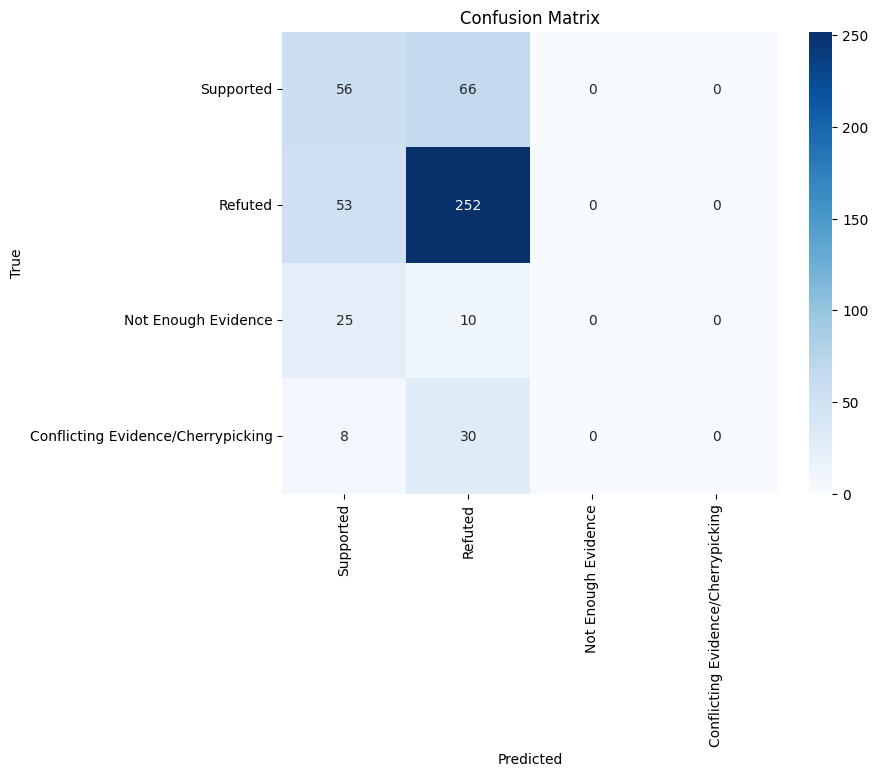

In [24]:
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# True vs Predicted
true_labels = test_df['labels']
pred_labels = preds.predictions.argmax(axis=1)

# Classification report
print("🔍 Classification Report:\n")
print(classification_report(true_labels, pred_labels, target_names=label2id.keys()))

# Accuracy
acc = accuracy_score(true_labels, pred_labels)
print(f"✅ Accuracy: {acc:.4f}")

# Confusion matrix
cm = confusion_matrix(true_labels, pred_labels)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=label2id.keys(), yticklabels=label2id.keys())
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

In [27]:
# id2label mapping
id2label = {
    0: "Supported",
    1: "Refuted",
    2: "Not Enough Evidence",
    3: "Conflicting Evidence/Cherrypicking"
}

# Build prediction JSON using dev_data (not test_df)
submission = []

for i, entry in enumerate(dev_data):
    claim = entry["claim"]
    pred_label = id2label[pred_labels[i]]

    top_evidences = retrieve_evidence_bm25_dpr(claim, top_k=3)

    evidence_entries = [
        {
            "question": "Claim validation?",
            "answer": ev,
            "url": "https://retrieved.source"  # Optional: replace with actual source URL if stored
        }
        for ev in top_evidences
    ]

    submission.append({
        "claim": claim,
        "pred_label": pred_label,
        "evidence": evidence_entries
    })

# Save JSON
with open("submission.json", "w", encoding="utf-8") as f:
    json.dump(submission, f, indent=2)

print("✅ Fixed: submission.json generated using dev_data['claim']")


✅ Fixed: submission.json generated using dev_data['claim']


In [29]:
import nltk
nltk.download('wordnet')

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\hasan\AppData\Roaming\nltk_data...


True

In [30]:
from evaluate_veracity import AVeriTeCEvaluator

# Load predictions and gold references
with open("submission.json") as f:
    predictions = json.load(f)

with open("dev.json") as f:
    references = json.load(f)

# Run the scorer
scorer = AVeriTeCEvaluator()
ev2r_scores = scorer.evaluate_averitec_score(predictions, references)

# Print scores across thresholds
print("\n📊 AVeriTeC Ev2R Scores:")
for i, level in enumerate(scorer.averitec_reporting_levels):
    print(f"  🔹 @ {level:.2f}: {ev2r_scores[i]:.4f}")



📊 AVeriTeC Ev2R Scores:
  🔹 @ 0.10: 0.5300
  🔹 @ 0.20: 0.1300
  🔹 @ 0.25: 0.0480
  🔹 @ 0.30: 0.0360
  🔹 @ 0.40: 0.0100
  🔹 @ 0.50: 0.0020


In [ ]:
print(test_df.columns)

Index(['text', 'label', 'labels', 'pred_label'], dtype='object')


In [31]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from datasets import Dataset
from sklearn.metrics import classification_report
import torch.nn.functional as F
import numpy as np

# Step 1: Load tokenizer and model
tokenizer = AutoTokenizer.from_pretrained("roberta-base")
model = AutoModelForSequenceClassification.from_pretrained("roberta-base", num_labels=4)

# Step 2: Rename label column
combined_df = combined_df.rename(columns={"label_id": "labels"})
test_df = test_df.rename(columns={"label_id": "labels"})

# Step 3: Tokenize
def tokenize(example):
    return tokenizer(example["text"], truncation=True, padding="max_length", max_length=512)

train_dataset = Dataset.from_pandas(combined_df[["text", "labels"]]).map(tokenize, batched=True)
test_dataset = Dataset.from_pandas(test_df[["text", "labels"]]).map(tokenize, batched=True)

# Step 4: Training setup
training_args = TrainingArguments(
    output_dir="./roberta-results",
    evaluation_strategy="epoch",
    save_strategy="epoch",
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=3,
    logging_dir="./logs",
    load_best_model_at_end=True,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
)

trainer.train()


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

c:\Users\hasan\AppData\Local\Programs\Python\Python312\Lib\site-packages\huggingface_hub\file_download.py:139: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\hasan\.cache\huggingface\hub\models--roberta-base. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

...

  0%|          | 0/63 [00:00<?, ?it/s]

{'eval_loss': 1.0099971294403076, 'eval_runtime': 7.704, 'eval_samples_per_second': 64.901, 'eval_steps_per_second': 8.178, 'epoch': 2.0}


  0%|          | 0/63 [00:00<?, ?it/s]

{'eval_loss': 1.0148602724075317, 'eval_runtime': 7.6835, 'eval_samples_per_second': 65.075, 'eval_steps_per_second': 8.199, 'epoch': 3.0}
{'train_runtime': 189.6871, 'train_samples_per_second': 15.816, 'train_steps_per_second': 1.977, 'train_loss': 0.9300341796875, 'epoch': 3.0}


TrainOutput(global_step=375, training_loss=0.9300341796875, metrics={'train_runtime': 189.6871, 'train_samples_per_second': 15.816, 'train_steps_per_second': 1.977, 'total_flos': 789347340288000.0, 'train_loss': 0.9300341796875, 'epoch': 3.0})

  0%|          | 0/63 [00:00<?, ?it/s]

🔍 Classification Report:

                                    precision    recall  f1-score   support

                         Supported       0.53      0.15      0.23       122
                           Refuted       0.64      0.97      0.77       305
               Not Enough Evidence       0.00      0.00      0.00        35
Conflicting Evidence/Cherrypicking       0.00      0.00      0.00        38

                          accuracy                           0.63       500
                         macro avg       0.29      0.28      0.25       500
                      weighted avg       0.52      0.63      0.52       500

✅ Accuracy: 0.6280


c:\Users\hasan\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\hasan\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\hasan\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

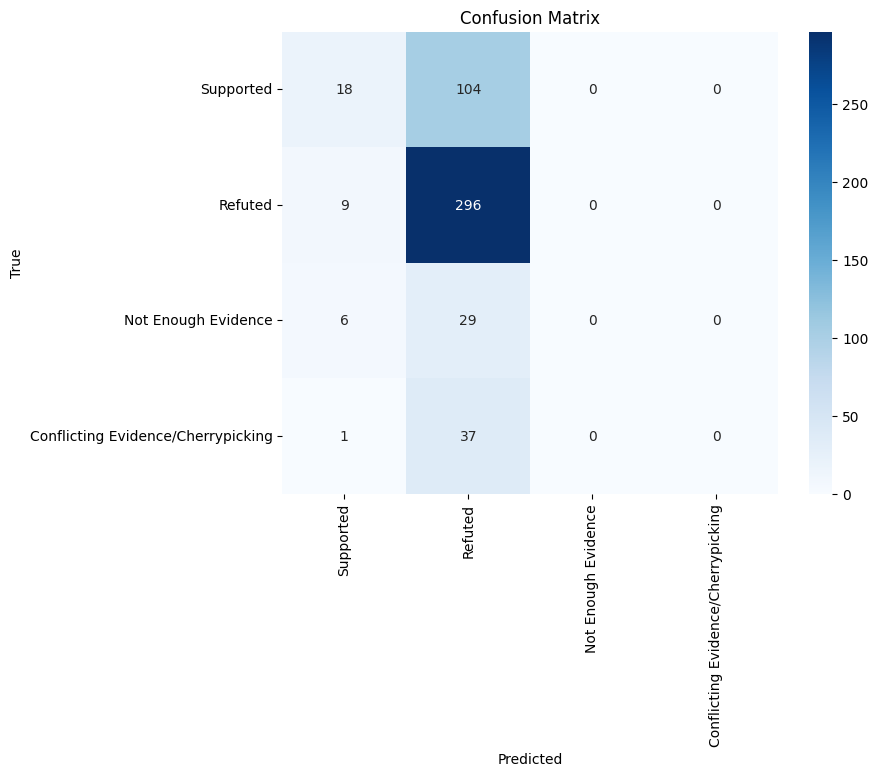

In [36]:
from sklearn.metrics import classification_report, confusion_matrix

# Get predictions
preds = trainer.predict(test_dataset)
pred_labels = np.argmax(preds.predictions, axis=1)

# Classification report
true_labels = test_df["labels"]
label_names = [
    "Supported",
    "Refuted",
    "Not Enough Evidence",
    "Conflicting Evidence/Cherrypicking"
]
print("🔍 Classification Report:\n")
print(classification_report(true_labels, pred_labels, target_names=label2id.keys()))

# Accuracy
acc = accuracy_score(true_labels, pred_labels)
print(f"✅ Accuracy: {acc:.4f}")

# Confusion matrix
cm = confusion_matrix(true_labels, pred_labels)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=label2id.keys(), yticklabels=label2id.keys())
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

In [37]:
from evaluate_veracity import AVeriTeCEvaluator


In [38]:
import json

# id2label for decoding predictions
id2label = {
    0: "Supported",
    1: "Refuted",
    2: "Not Enough Evidence",
    3: "Conflicting Evidence/Cherrypicking"
}

# Use dev_data (original dataset with claim + questions)
submission = []
for i, entry in enumerate(dev_data):
    claim = entry["claim"]
    pred_label = id2label[pred_labels[i]]
    top_evidence = retrieve_evidence_bm25_dpr(claim, top_k=3)

    evidence_entries = [
        {
            "question": "Claim validation?",
            "answer": ev,
            "url": "https://retrieved.source"
        }
        for ev in top_evidence
    ]

    submission.append({
        "claim": claim,
        "pred_label": pred_label,
        "evidence": evidence_entries
    })

with open("submission.json", "w") as f:
    json.dump(submission, f, indent=2)

# Evaluate
with open("dev.json") as f:
    references = json.load(f)

scorer = AVeriTeCEvaluator()
scores = scorer.evaluate_averitec_score(submission, references)

print("\n📊 AVeriTeC Ev2R Scores:")
for i, level in enumerate(scorer.averitec_reporting_levels):
    print(f"  🔹 @ {level:.2f}: {scores[i]:.4f}")



📊 AVeriTeC Ev2R Scores:
  🔹 @ 0.10: 0.5360
  🔹 @ 0.20: 0.1120
  🔹 @ 0.25: 0.0360
  🔹 @ 0.30: 0.0260
  🔹 @ 0.40: 0.0060
  🔹 @ 0.50: 0.0000
